# Clasificación con redes neuronales

En este notebook simple usaremos una FCNN (completamente conectada) para resolver el problema de clasificación de ID de partículas, visto previamente para SVMs.

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

In [1]:
#Para esta actividad se trabaja de manera remota subiendo los archivos a Colab
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [3]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
matplotlib.rcParams['figure.dpi'] = 300

### Librerías para Deep Learning

[Tensorflow](https://www.tensorflow.org/?hl=es-419) es una biblioteca de uso muy común para el desarrollo de modelos de aprendizaje profundo. Es una plataforma de código abierto desarrollada por Google. Admite programación en varios lenguajes, como C++, Java, Python, y muchos otros.

[Keras](https://keras.io/) es una API de alto nivel (Application Programming Interface) construida sobre TensorFlow (o Theano, otra biblioteca de aprendizaje profundo). Es específica para Python, y podemos pensar en ella como el equivalente de la biblioteca sklearn, pero para redes neuronales. Es menos general y menos personalizable, pero muy fácil de usar y comparativamente más sencilla que TensorFlow.

[PyTorch](https://pytorch.org/) es otra biblioteca muy popular para el desarrollo de modelos de aprendizaje profundo, desarrollada por Meta (Facebook). A diferencia de Keras, no es una API de alto nivel sobre otra biblioteca, sino un framework completo en sí mismo. Es especialmente popular en investigación por su flexibilidad para construir arquitecturas no estándar, aunque eso viene con una curva de aprendizaje más pronunciada y bastante más código para tareas simples.

En este curso usaremos Keras con TensorFlow como back-end, porque para los problemas que veremos su simplicidad tiene más peso que la flexibilidad extra de PyTorch.

**Comparación**

| | TensorFlow | Keras | PyTorch |
|---|---|---|---|
| **Qué es** | Framework completo | API de alto nivel (sobre TensorFlow) | Framework completo |
| **Desarrollado por** | Google | Ahora integrado a TensorFlow | Meta (Facebook) |
| **Curva de aprendizaje** | Media-alta | Baja | Media-alta |
| **Líneas de código para un modelo simple** | Muchas | Pocas | Muchas |
| **Flexibilidad para arquitecturas no estándar** | Alta | Media | Muy alta |
| **Dónde se usa más** | Producción, industria | Prototipado rápido, docencia | Investigación, papers recientes |


In [4]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
#!pip install tensorflow

In [6]:
import tensorflow as tf

In [7]:
tf.__version__

'2.20.0'

Importamos `keras` y usaremos `Sequential`, que admite una entrada y una salida

In [8]:
import keras

from keras.models import Sequential # El modelo se construye agregando una capa después de otra

from keras.layers import Dense #totalmente conectadas: cada output se conecta con cada input

from keras.layers import Dropout #para regularización

Comenzamos con el problema de 4top vs ttbar, y utilizamos la configuración en la que añadimos las características "número de leptones", "número de jets", etc. Como referencia, el SVM óptimo alcanzó un 94-95% de precisión. Cabe destacar que esos números no se obtuvieron utilizando validación cruzada anidada, por lo que podrían ser ligeramente optimistas.

In [9]:
#X = pd.read_csv('/content/drive/MyDrive/AST332_ML/Features_lim_2.csv')

In [10]:
#y = np.genfromtxt('/content/drive/MyDrive/AST332_ML/Labels_lim_2.txt')

In [11]:
X = pd.read_csv("Features_lim_2.csv")
y = np.genfromtxt("Labels_lim_2.txt")

In [12]:
X.values.shape

(5000, 24)

In [13]:
X.head()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0


In [14]:
y

array([0., 0., 0., ..., 0., 1., 0.])

Aquí no hay un proceso de validación cruzada "integrado", por lo que tendríamos que implementarlo nosotros mismos. Por ahora, podemos construir tres conjuntos: entrenamiento, validación (para la optimización de parámetros) y prueba (para la evaluación final). Idealmente, deberíamos estructurarlo como una validación cruzada.

En la práctica, rara vez se hace CV k-fold completa con redes neuronales. Cada fold implica reentrenar la red desde cero, así que el costo computacional escala rápido: con 5 folds ya estamos pagando 5 veces el costo de entrenamiento, y eso antes de siquiera empezar a buscar hiperparámetros. Además, la razón principal para usar CV es obtener una estimación confiable del desempeño cuando el dataset es chico; con datasets grandes (el escenario típico donde las NN funcionan mejor), un solo split bien hecho ya da una estimación razonablemente estable.

Por eso optamos por un split fijo train/validación/prueba, y usamos el set de validación para *early stopping* y ajuste de hiperparámetros. Esto evita el costo de CV sin sacrificar demasiado rigor.

#### Sets de entrenamiento y prueba

Este dataset tiene un desbalance importante entre las dos clases. Para que esa proporción se mantenga en cada split, usamos `stratify` al dividir los datos.

In [15]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total)))

{np.float64(0.0): np.int64(4189), np.float64(1.0): np.int64(811)}


In [16]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.19


In [17]:
# Primero separamos test (20%), estratificado por clase
X_temp, X_test, y_temp, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=10 # Stratify nos ayuda con el desbalance (se mantienen las proporciones)
)

# Del resto, separamos train/val (80/20 de lo que queda)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=10
)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(3200, 24) (800, 24) (1000, 24)
Balance train: 0.1621875 | val: 0.1625 | test: 0.162


### Construyendo la red

Pensemos en la arquitectura del modelo.

Nuestra capa de entrada tiene **24 neuronas** (24 características)

Nuestra capa de salida tiene **una neurona** (la salida es la probabilidad de que el objeto pertenezca a la clase positiva). También podríamos configurarla con dos neuronas (y usar softmax como la no linealidad final), pero esto es redundante en un problema de clasificación binaria. La neurona de salida será una función **sigmoide**

Añadiremos **dos capas ocultas**. En este caso, ambas tienen tamaño = 20 (debemos optimizar este hiperparámetro!). También podemos reservar la posibilidad de añadir una capa de dropout después de cada una.

Otras decisiones que debemos tomar son: qué no linealidades usar (por ahora: ReLU para las capas ocultas, sigmoide para la final), qué optimizador usar (Adam), qué tasa de aprendizaje inicial adoptar (aquí 0.001, aunque nuevamente esto debería decidirse mediante CV), el número de épocas (por ejemplo, 100; podemos graficar cantidades de interés para verificar que esto sea suficiente), el tamaño de lote (batch size) para el paso de descenso por gradiente (aquí 0.001, pero podemos explorarlo!) y la función de pérdida. Esta última es la entropía cruzada binaria ([binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)), que es la elección estándar para problemas de clasificación donde la salida es una probabilidad. Premia la "confianza" en una predicción correcta (alta probabilidad).

El siguiente comando nos ayuda a explorar todas las posibles opciones

In [18]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [19]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

La opción estándar para un caso como el nuestro, donde las etiquetas son 0/1, pero podemos predecir una probabilidad, es binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

$p$ es la probabilidad de que un objeto pertenezca a la clase positiva. Penaliza los ejemplos positivos que están asociados con una probabilidad predicha baja, y los ejemplos negativos que están asociados con una probabilidad predicha alta.


Acá una lista de funciones de activación

In [20]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

### Así es como construímos la red completamente conectada en Keras

In [21]:
model = Sequential() # red secuencial

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid'))

model.summary() # resumen de la arquitectura



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) # usamos el optimizador Adam

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

Con el keyword `métrica` podemos cambiar a la métrica que queremos ver. El valor absoluto de la pérdida no se traduce directamente en algo intuitivo (a diferencia de accuracy, que sí es un % de aciertos), aunque sigue siendo muy útil para comparar train vs. validación y detectar overfitting.

### Ahora pruebe usted

Usando el mismo código de arriba como plantilla, modifíquelo para responder:

**¿Qué pasa si agrega una tercera capa oculta?** Agréguela (por ejemplo, de tamaño 20 también) y comenten: ¿por qué una arquitectura más profunda podría ayudar o no ayudar en este problema?

**¿Qué pasa si cambia el tamaño de las capas ocultas** (por ejemplo, de 20 a 5, o de 20 a 100)? Antes de correrlo: ¿espera que la red sea más lenta o más rápida de entrenar? ¿Más o menos propensa a sobreajustar?

**¿Qué pasa si usa otra función de activación** en las capas ocultas (por ejemplo `tanh` en vez de `relu`)? Revise la lista de activaciones disponibles que exploramos arriba con `dir(keras.activations)`.

No hace falta entrenar todavía, solo construyan el modelo con `model.summary()` al final y observe cómo cambia el número de parámetros totales según sus decisiones.


Respuestas:
1. Al agregar más capas ocultas la red se vuelve más compleja y le permite ajustarse mejor a los datos, pero a la vez aumenta el riesgo de sobreajustar.
2. Probando con ambos casos:
    - Con 5 neuronas: Se simplifica el ajuste, de forma que la red se vuelve mucho más pequeña y entrena más rápido, pero generaliza demasiado, tendiendo a subajustar.
    - con 100 neuronas: Al tener una cantidad tan alta de neuronas, se vuelve mucho más grande y más lento por consecuencia, lo que también tiende a sobreajustar.
3. si probamos la función `tanh` de activación, cambiaremos a una no linealidad. Los resultados visuales en comparación con `relu` son relativamente similares.

In [23]:
#Probaremos parámetros distintos
model_mod = Sequential() # red secuencial

# Primera capa oculta, donde probaremos menos neuronas (5 en este caso)

model_mod.add(Dense(5, activation='tanh', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño

model_mod.add(Dense(5, activation='tanh'))

# Agregaremos una tercera capa oculta
model_mod.add(Dense(5, activation='tanh'))

# Agrega capa de salida

model_mod.add(Dense(1, activation='sigmoid'))

model_mod.summary() # resumen de la arquitectura



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 5)              │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
#Optimizamos el modelo modificado
optimizer_mod = tf.keras.optimizers.Adam(learning_rate=0.001) # usamos el optimizador Adam

model_mod.compile(loss='binary_crossentropy', optimizer=optimizer_mod, metrics = ['accuracy'])

### Listos para ajustar!

Nota también los hiperparámetros adicionales "epochs" (el número de pasadas completas de ida y vuelta sobre el conjunto de datos) y "batch size" (cuántos datos se utilizan en cada paso para actualizar los pesos).

### Antes de correr esto

¿Qué accuracy espera que logre esta red? Como referencia, el SVM óptimo llegó a 94-95%. Escriba su predicción antes de correr la celda de abajo.

> Mi predicción de accuracy:
Considerando que este caso es uno de clasificación, se espera tener un accuracy relativamente alto, rondando el 80% si es que predecimos las clases mayoritarias.

In [25]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5000 - loss: 12125.9883 - val_accuracy: 0.7262 - val_loss: 7161.3589
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6959 - loss: 6061.6704 - val_accuracy: 0.5738 - val_loss: 4017.7742
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5925 - loss: 3459.1995 - val_accuracy: 0.7000 - val_loss: 2352.7063
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 2064.2251 - val_accuracy: 0.7050 - val_loss: 1680.6763
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6806 - loss: 1559.3679 - val_accuracy: 0.6737 - val_loss: 1449.9797
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6772 - loss: 1314.5959 - val_accuracy: 0.6950 - val_loss: 1195.0579
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6891 - loss: 1151.2996 - val_accuracy: 0.6888 - val_loss: 1124.5875
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.67

Accuracy para entrenamiento y validación no se ven muy bien

Grafiquemos cómo se ve esto en cada época

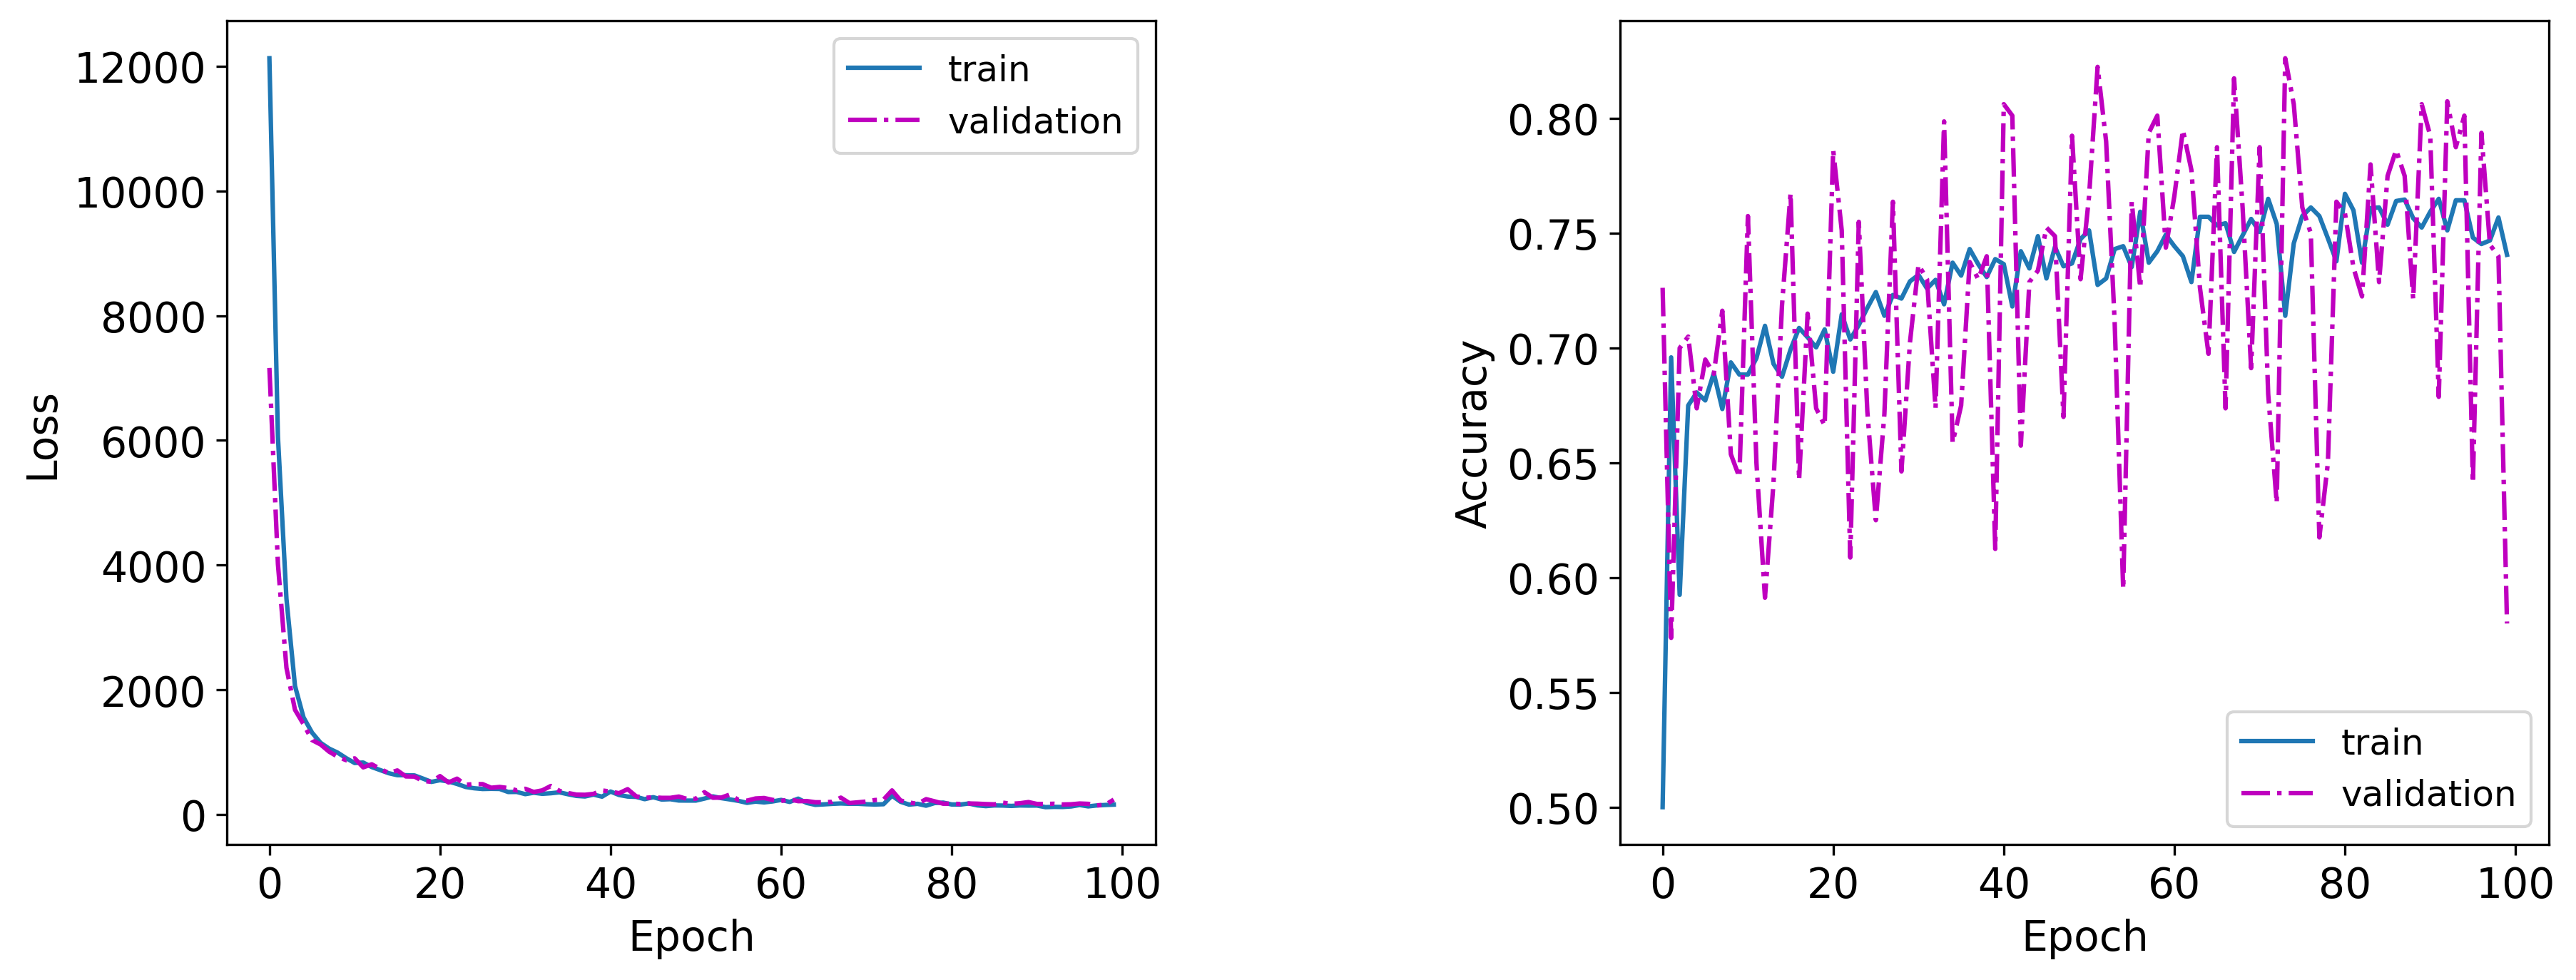

In [26]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

In [27]:
#Probando el modelo modificado (para comparación visual)
mynet_mod = model_mod.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7203 - loss: 0.6401 - val_accuracy: 0.7075 - val_loss: 0.6243
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7184 - loss: 0.6092 - val_accuracy: 0.7138 - val_loss: 0.5960
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7688 - loss: 0.5813 - val_accuracy: 0.7900 - val_loss: 0.5687
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7919 - loss: 0.5566 - val_accuracy: 0.7900 - val_loss: 0.5443
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8209 - loss: 0.5340 - val_accuracy: 0.8375 - val_loss: 0.5250
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8375 - loss: 0.5163 - val_accuracy: 0.8375 - val_loss: 0.5076
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8375 - loss: 0.5002 - val_accuracy: 0.8375 - val_loss: 0.4915
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8375 - loss: 0.4862 - val_accuracy: 0.8375 - 

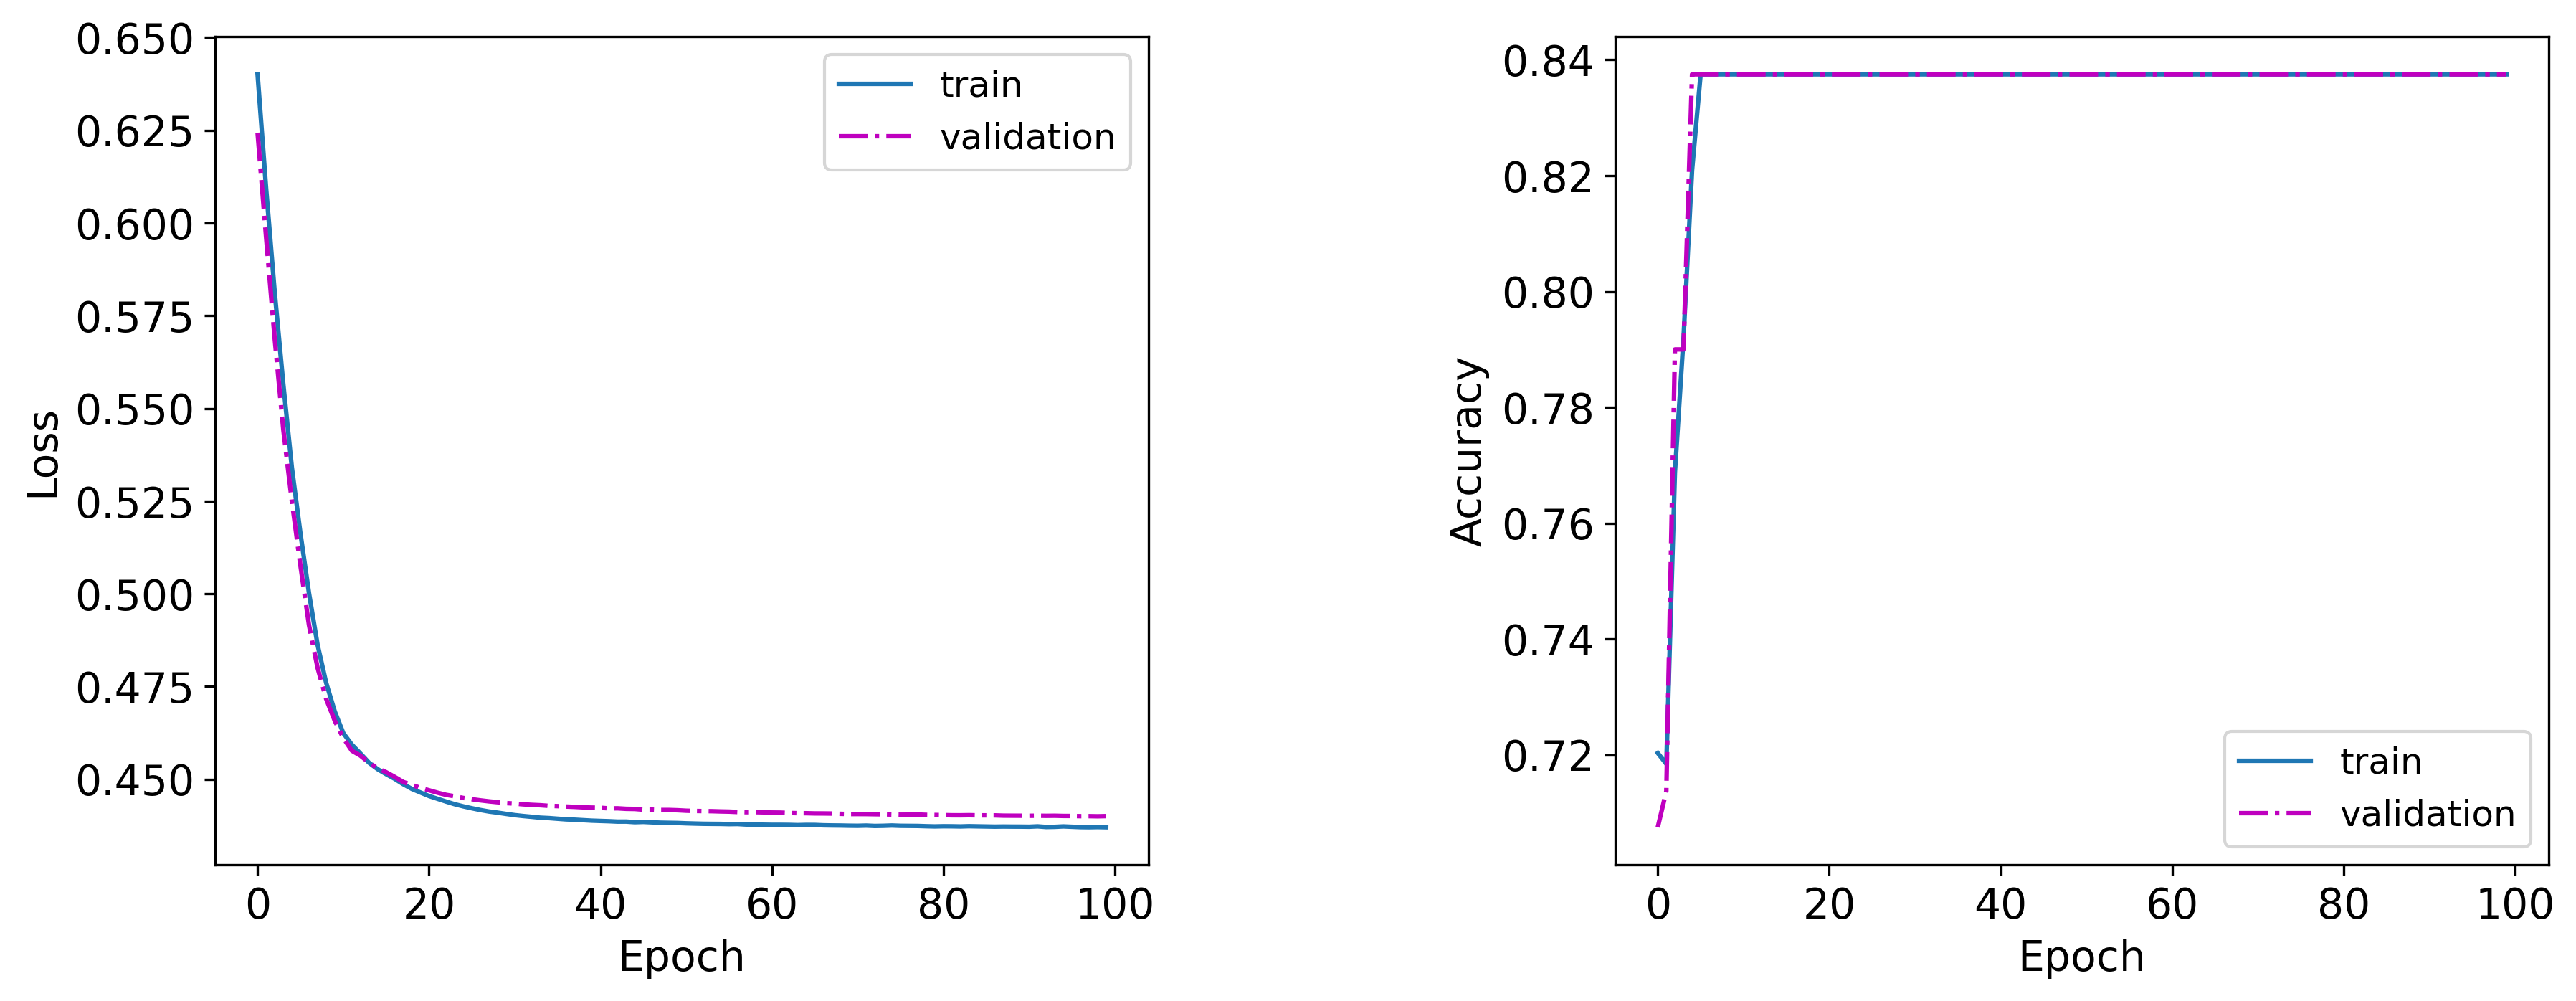

In [28]:
#Para visualizar el modelo modificado
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_mod.history['loss'], label = 'train')
plt.plot(mynet_mod.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_mod.history['accuracy'], label = 'train')
plt.plot(mynet_mod.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

### Diagnóstico

El accuracy salió mucho peor de lo esperado. Antes de seguir:

1. Corra `X.describe()` en la celda de abajo y miren los rangos (min, max, mean) de las distintas columnas.
2. ¿Ve algo que podría estar afectando el entrenamiento por gradiente descendiente?
3. Le parece que la curva de la pérdida es suficiente para el diagnóstico del modelo?

Respuestas:

2. Si analizamos X.describe(), notaremos que las features tienen rangos de magnitudes muy disintos. Algunas variables como P1 y P4 tienen valores de orden de varios ceros, mientras que otros como P3 son de orden 1. Esta diferencia afecta directamente el descenso por gradiente por la forma en la que este converge e inflando los gradientes.


3. La curva de pérdida, aunque se ve óptima y describe bien que tan bien son las predicciones, no puede indicar directamente si el modeo aprende de clases variadas. Es por eso que necesitamos ver también la curva del accuracy, que notamos es bastante poco precisa.

In [29]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


### Nos olvidamos de escalar (por qué es necesario??)

Escalar es necesario debido a la forma en la que el gradiente de pérdida se calcula. Cuando una variable tiene valores de grandes ordenes y la otra de orden 1, el gradiente respectivo a los pesos será desproporcionalmente grande y esto se irá acumulando a medida que se van añadiendo más variables. Al escalar todas las features, generamos un equilibrio que evita el desbalance.

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

Escalamos sólo los datos del set entrenamiento (para evitar leakage)

In [32]:
scaler.fit(X_train)

StandardScaler()

In [33]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

### Reentrenamos la red

In [34]:
model_st = Sequential()
model_st.add(Dense(20, activation='relu', input_shape=(24,)))
model_st.add(Dense(20, activation='relu'))
model_st.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_st.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_st = model_st.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0) #verbose=0 para no mostrar el resultado en cada epoca

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
print(f"Validation Accuracy para tres capas: {mynet_st.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss para tres capas: {mynet_st.history['val_loss'][-1]:.4f}")

Validation Accuracy para tres capas: 0.9475
Validation Loss para tres capas: 0.1609


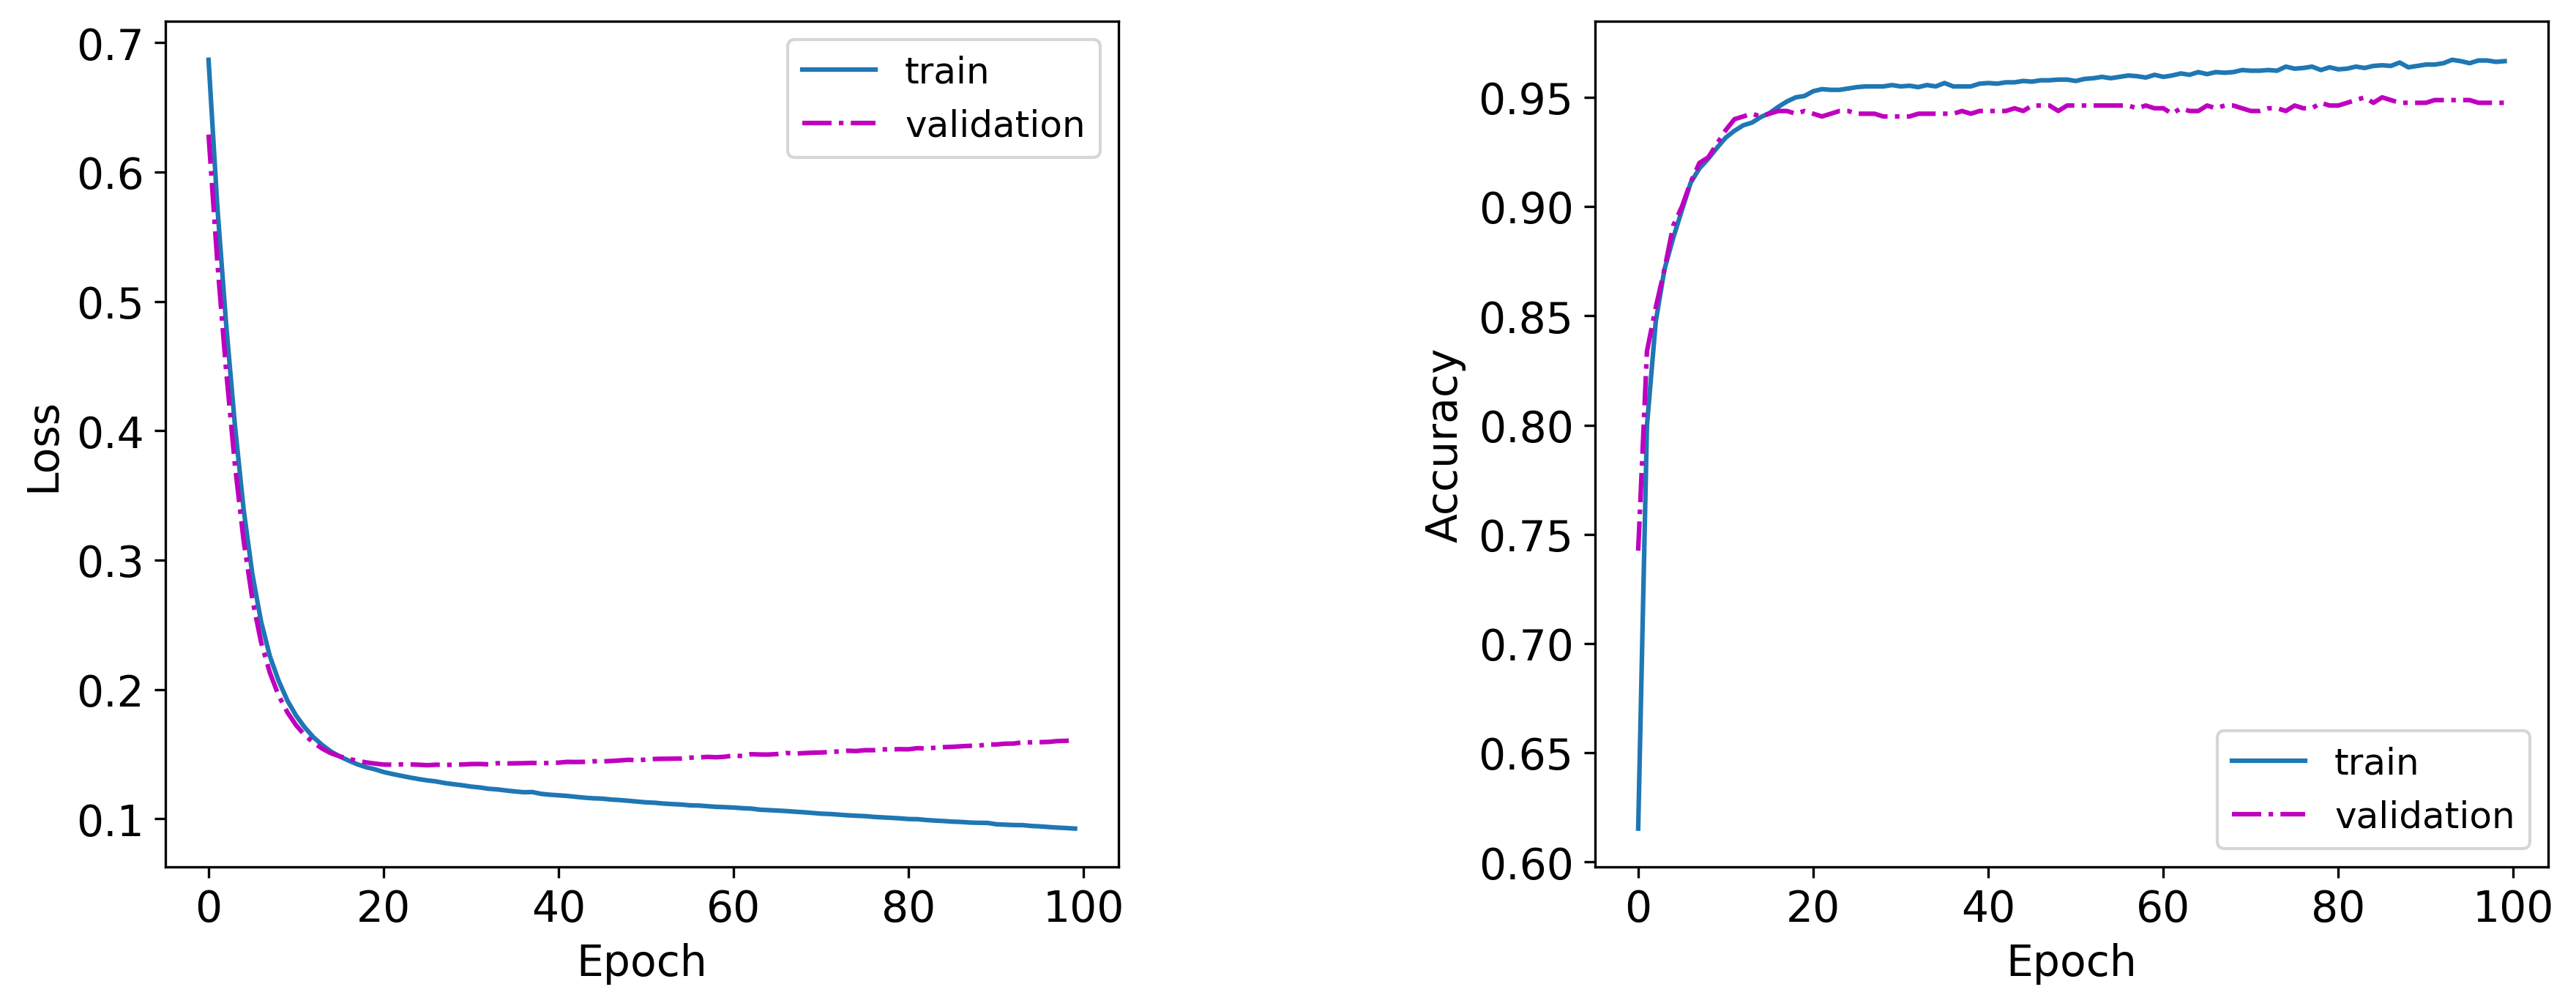

In [36]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_st.history['loss'], label = 'train')
plt.plot(mynet_st.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_st.history['accuracy'], label = 'train')
plt.plot(mynet_st.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

#### Ahora se ve mucho mejor el comportamiento de la red, y además se alcanza un accuracy similar a lo que obtuvimos con SVMs

Esto es común para datos tabulares, que tienen relaciones más simples y en general no contienen demasiados datos. Las NN funcionan mejor para datos más complejos, como audio, imágenes, texto

### Diagnóstico

Mire las curvas de loss y accuracy  (train vs. validación, con datos escalados).

1. ¿Hay separación entre las curvas de train y validación? ¿Es una separación que se mantiene estable, o una que crece con las épocas?
2. ¿esto califica como overfitting severo, overfitting leve, o no hay overfitting? Justifique mirando específicamente sus números, no una regla general.
3. Según su diagnóstico, ¿tiene sentido aplicar regularización acá, o el modelo ya está bien como está?


Respuestas:

1. Sí la hay, aunque es pequeña. El train queda un poco debajo de la curva de validación en el gráfico de pérdida y un poco más arriba de la curva de validación en el gráfico de accuracy. A medida que avanzan las épocas, estas separaciones se abren un poco más.

2. En si, se ajusta bien a las curvas de validación, pero a medida que pasan varias épocas se van separando, lo que puede indicar un overfitting leve. Aunque la brecha es pequeña, sigue estando y aumentando.

3. En este caso, ya hay una generalización bastante buena. Pero debido a que existe esta brecha que aumenta es buena idea reducirla lo más posible regularizando.

### Ahora pruebe usted

La red original cuenta con dos capas ocultas de 20 neuronas cada una, ReLU, y salida sigmoide, entrenada con datos escalados. Usando ese mismo código como plantilla, construya y entrene tres variantes, una a la vez:

1. **Agregue una tercera capa oculta** (de 20 neuronas también). ¿Mejora, empeora, o no cambia mucho el accuracy de validación? ¿Por qué creen que pasa eso en este dataset específico?

2. **Cambie el tamaño de las capas ocultas** a algo mucho más chico (5 neuronas) y después a algo mucho más grande (100 neuronas). ¿Cuál entrena más lento? ¿Cuál muestra más señales de sobreajuste en las curvas de loss?

3. **Cambie la activación** de las capas ocultas de `relu` a `tanh`. Usen `dir(keras.activations)` si quieren ver más opciones. ¿Cambia la velocidad de convergencia?

Rellene la tabla de comparación

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) | 0.9312 | 0.1702 | La referencia inicial |
| 3 capas ocultas | 0.9337 | 0.2032 | Relativamente similar por la baja complejidad de la red, por lo que no hay mejora ni empeora significativa |
| Capas de 5 neuronas | 0.9463 | 0.1508 | Menos neuronas implica una red más simple, es decir, un subajuste |
| Capas de 100 neuronas | 0.9287 | 0.7728 | Más neuronas implica una red más compleja, es decir, un sobreajuste|
| Activación tanh | 0.940 | 0.1691 | Converge similar a ReLU |


Respuestas:
1. Para la tercera capa no hay una mejora realmente significativa debido a que la complejidad de la capa no es suficiente. Esto lo podemos notar que el número de parámetros sube de 421 a 1.361 sin una ganancia notoria en el accuracy y loss validation. RESPONDER POR QUE PASA ESTO

2. La red que se entrena mucho más lento es la de cien neuronas por capa y la que tiende a un sobreajuste resulta ser el de cien neuronas.

3. La velocidad es relativamente más lenta que ReLU, pero no lo suficiente para ser declaratoria.



In [37]:
#Código para probar los tres modelos distintos

#Primero probamos con el modelo con tres capas ocultas de 20 neuronas
model_layers = Sequential()

model_layers.add(Dense(20, activation = "relu", input_shape=(24,)))
model_layers.add(Dense(20, activation = "relu"))
model_layers.add(Dense(20, activation = "relu"))

model_layers.add(Dense(1, activation = "sigmoid"))
model_layers.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
optimizer_layers = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_layers.compile(loss = "binary_crossentropy", optimizer = optimizer_layers, metrics = ["accuracy"])

In [39]:
net_layers = model_layers.fit(Xst_train, y_train, validation_data = (Xst_val, y_val), epochs = 100, batch_size = 200, verbose = 0)

#Para poder ver los resultados del accuracy y el loss después del entrenamiento
print(f"Validation Accuracy para tres capas: {net_layers.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss para tres capas: {net_layers.history['val_loss'][-1]:.4f}")

Validation Accuracy para tres capas: 0.9300
Validation Loss para tres capas: 0.2220


In [40]:
#Ahora probamos con el modelo cambiando la cantidad de neuronas (probaremos 5 y 100)
#Modelo con 5 neuronas
model_five_n = Sequential()

model_five_n.add(Dense(5, activation = "relu", input_shape=(24,)))
model_five_n.add(Dense(5, activation = "relu"))

model_five_n.add(Dense(1, activation = "sigmoid"))

#Modelo con 100 neuronas
model_lot_n = Sequential()

model_lot_n.add(Dense(100, activation = "relu", input_shape=(24,)))
model_lot_n.add(Dense(100, activation = "relu"))

model_lot_n.add(Dense(1, activation = "sigmoid"))

model_five_n.summary()
model_lot_n.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 5)              │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,701 (49.61 KB)

 Trainable params: 12,701 (49.61 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
#Para las cinco neuronas
optimizer_five_n = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_five_n.compile(loss = "binary_crossentropy", optimizer = optimizer_five_n, metrics = ["accuracy"])

#Para las cien neuronas
optimizer_lot_n = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_lot_n.compile(loss = "binary_crossentropy", optimizer = optimizer_lot_n, metrics = ["accuracy"])

#Red de cinco neuronas
net_five_n = model_five_n.fit(Xst_train, y_train, validation_data = (Xst_val, y_val), epochs = 100, batch_size = 200, verbose = 0)
#Red de cien neuronas
net_lot_n = model_lot_n.fit(Xst_train, y_train, validation_data = (Xst_val, y_val), epochs = 100, batch_size = 200, verbose = 0)

#Para poder ver los resultados del accuracy y el loss después del entrenamiento
print(f"Validation Accuracy de 5 neuronas: {net_five_n.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss de 5 neuronas: {net_five_n.history['val_loss'][-1]:.4f}")
print ("--------------------")
print(f"Validation Accuracy de 100 neuronas: {net_lot_n.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss de 100 neuronas: {net_lot_n.history['val_loss'][-1]:.4f}")

Validation Accuracy de 5 neuronas: 0.9400
Validation Loss de 5 neuronas: 0.1516
--------------------
Validation Accuracy de 100 neuronas: 0.9250
Validation Loss de 100 neuronas: 0.4008


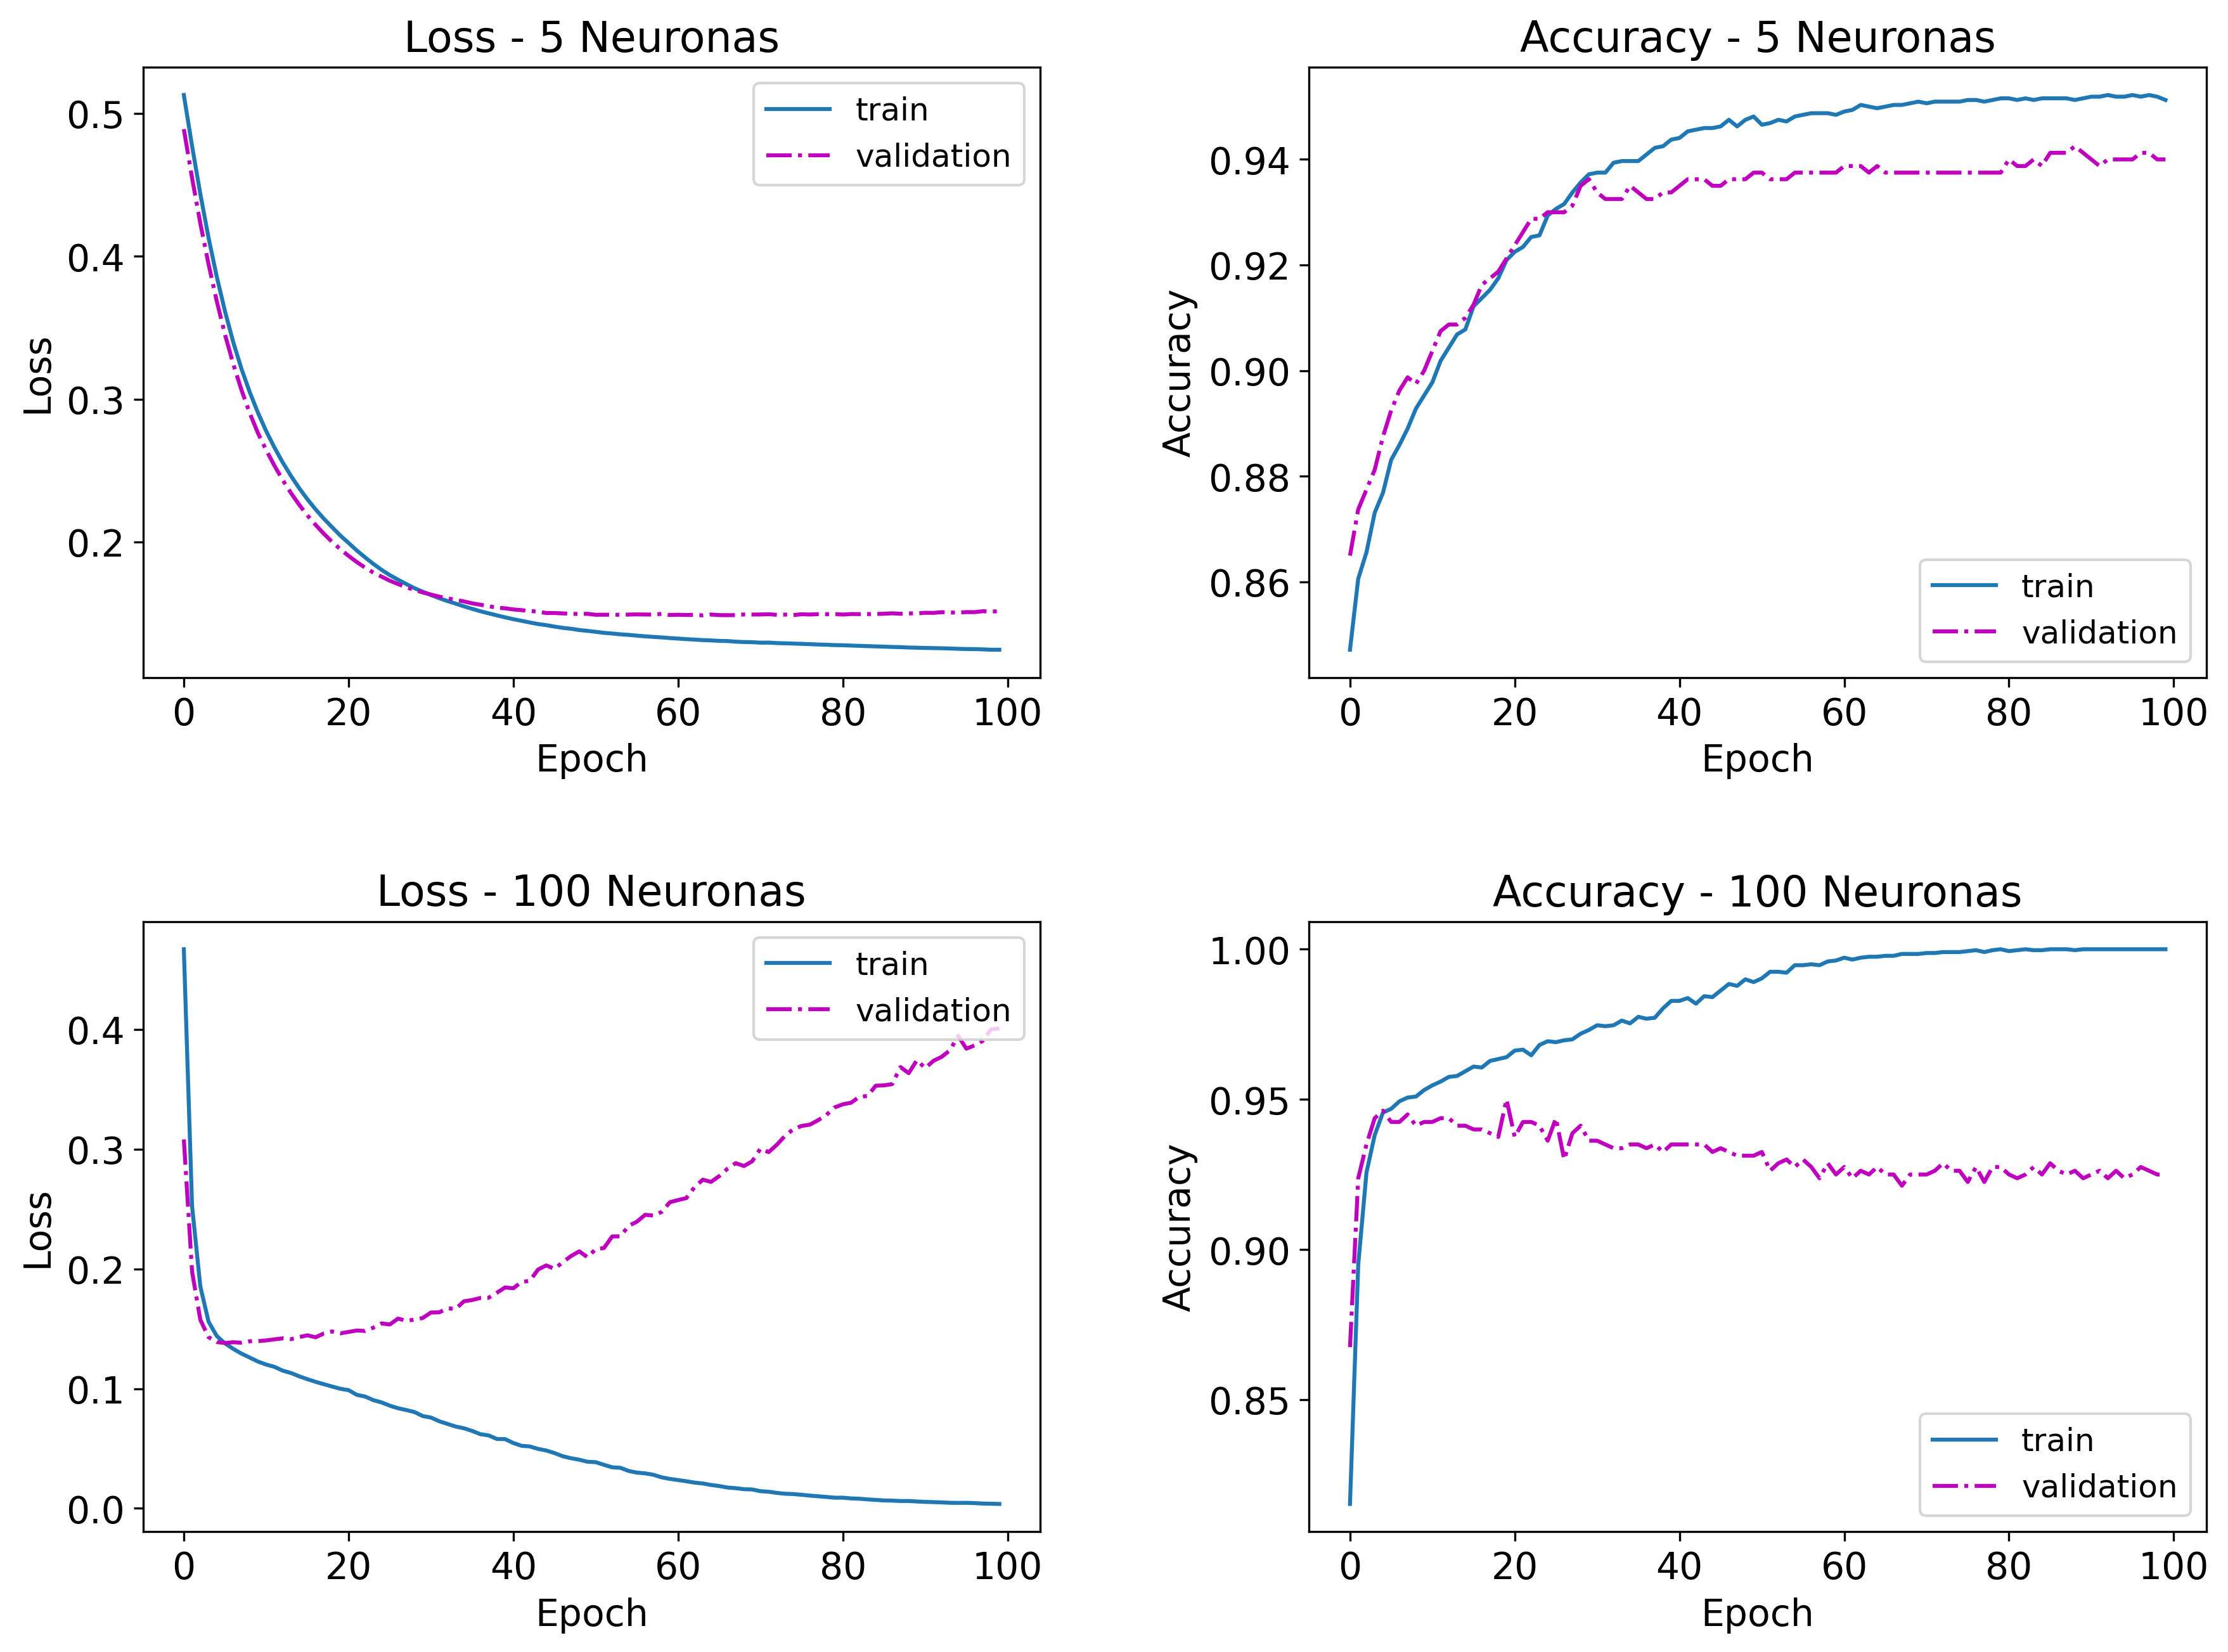

In [42]:
plt.figure(figsize=(14,10))

plt.subplot(221)
plt.plot(net_five_n.history['loss'], label = 'train')
plt.plot(net_five_n.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title('Loss - 5 Neuronas', fontsize = 16)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(222)
plt.plot(net_five_n.history['accuracy'], label = 'train')
plt.plot(net_five_n.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title('Accuracy - 5 Neuronas', fontsize = 16)
plt.legend(fontsize = 12)

plt.subplot(223)
plt.plot(net_lot_n.history['loss'], label = 'train')
plt.plot(net_lot_n.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title('Loss - 100 Neuronas', fontsize = 16)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(224)
plt.plot(net_lot_n.history['accuracy'], label = 'train')
plt.plot(net_lot_n.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title('Accuracy - 100 Neuronas', fontsize = 16)
plt.legend(fontsize = 12)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

In [43]:
#Para la última variante cambiamos loa activación a tanh

model_tanh = Sequential()

model_tanh.add(Dense(20, activation = "tanh", input_shape=(24,)))
model_tanh.add(Dense(20, activation = "tanh"))

model_tanh.add(Dense(1, activation = "sigmoid"))
model_tanh.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
optimizer_tanh = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_tanh.compile(loss = "binary_crossentropy", optimizer = optimizer_tanh, metrics = ["accuracy"])

net_tanh = model_tanh.fit(Xst_train, y_train, validation_data = (Xst_val, y_val), epochs = 100, batch_size = 200, verbose = 0)

print(f"Validation Accuracy para activación tanh: {net_tanh.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss para activación tanh: {net_tanh.history['val_loss'][-1]:.4f}")

Validation Accuracy para activación tanh: 0.9362
Validation Loss para activación tanh: 0.1747


### Regularización (por qué es necesaria??)

Dos estrategias razonables acá: parar el entrenamiento antes (**early stopping**, ~época 20-30,
donde val deja de mejorar), o agregar regularización con **dropout** y ver si empuja la curva de validación
más alto. Probemos ambas y comparemos.

### Antes de correr

Va a probar dos estrategias para esta brecha train/val: dropout y early stopping. Antes de correr ninguna:

- ¿Cuál de las dos cree que va a dar mejor accuracy en validación?
- ¿Cuál cree que va a ser más rápida de entrenar (menos épocas efectivas)?


Respuestas:
1. Se espera que early stopping obtenga un mejor accuracy de validación, ya que el overfitting observado va creciendo a medida que pasan las épocas. Por ende, detener el entrenamiento en el punto exacto donde la pérdida deja de mejorar podría capturar mejor la generalización.

2. Early stopping, ya que simplemente deja de trabajar según la cantidad de épocas señaladas.

### Dropout

In [45]:
model_dropout = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_dropout.add(Dense(20, activation='relu', input_shape=(24,)))

model_dropout.add(Dropout(0.2)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_dropout.add(Dense(20, activation='relu'))

model_dropout.add(Dropout(0.2)) #fracción de dropout

#Agregamos capa de salida

model_dropout.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_dropout.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [46]:
mynet_dropout = model_dropout.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

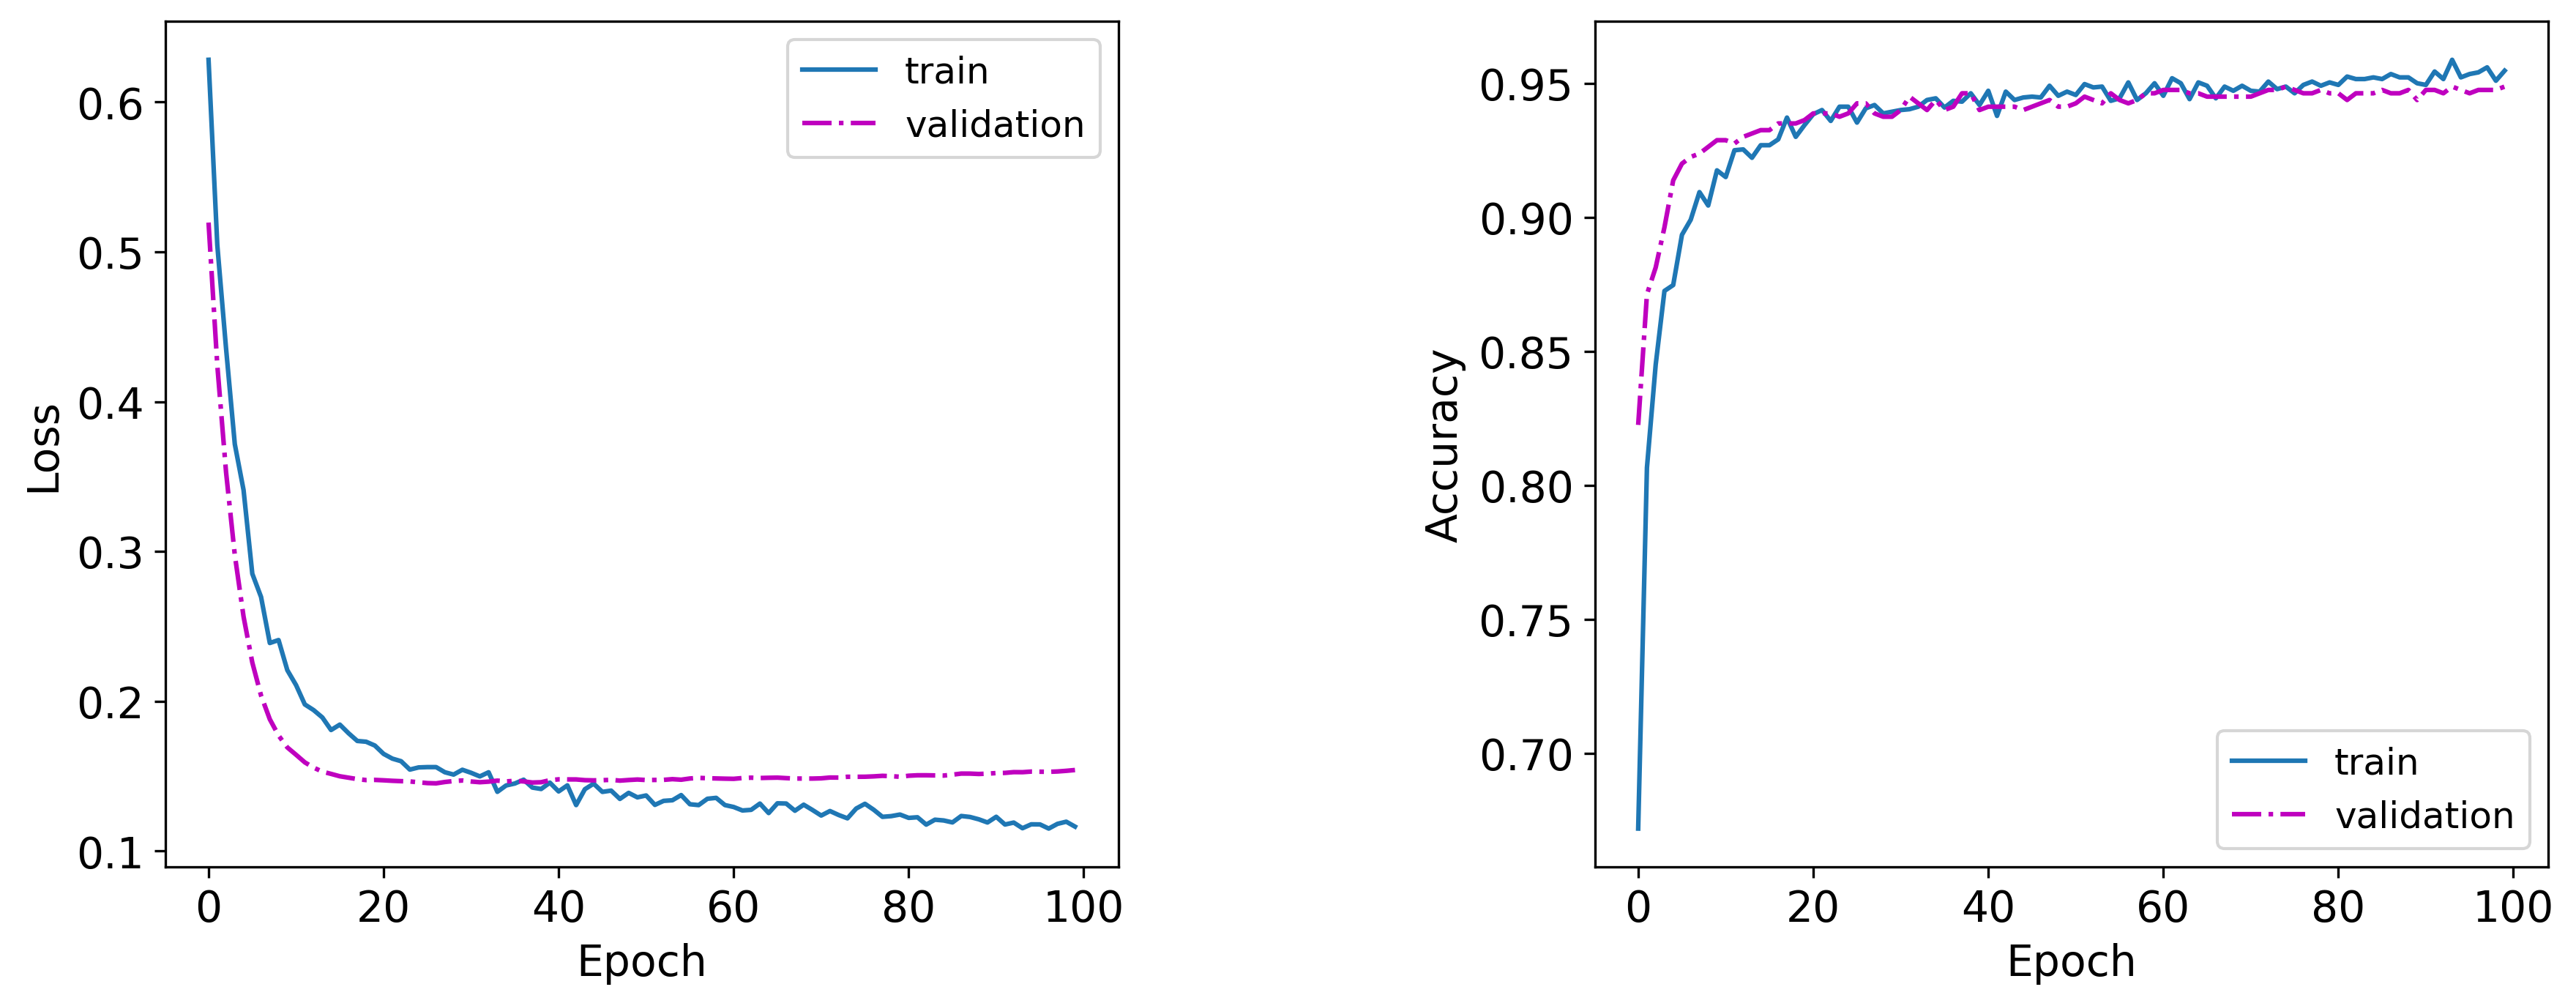

In [47]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_dropout.history['loss'], label = 'train')
plt.plot(mynet_dropout.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_dropout.history['accuracy'], label = 'train')
plt.plot(mynet_dropout.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

### Early Stopping

In [48]:
from tensorflow.keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Dense(20, activation='relu', input_shape=(24,)))
model_early.add(Dense(20, activation='relu'))
model_early.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_early.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

mynet_early = model_early.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, callbacks=[early_stop], verbose=0)

print(f"Se detuvo en la época: {len(mynet_early.history['loss'])}")

Se detuvo en la época: 36


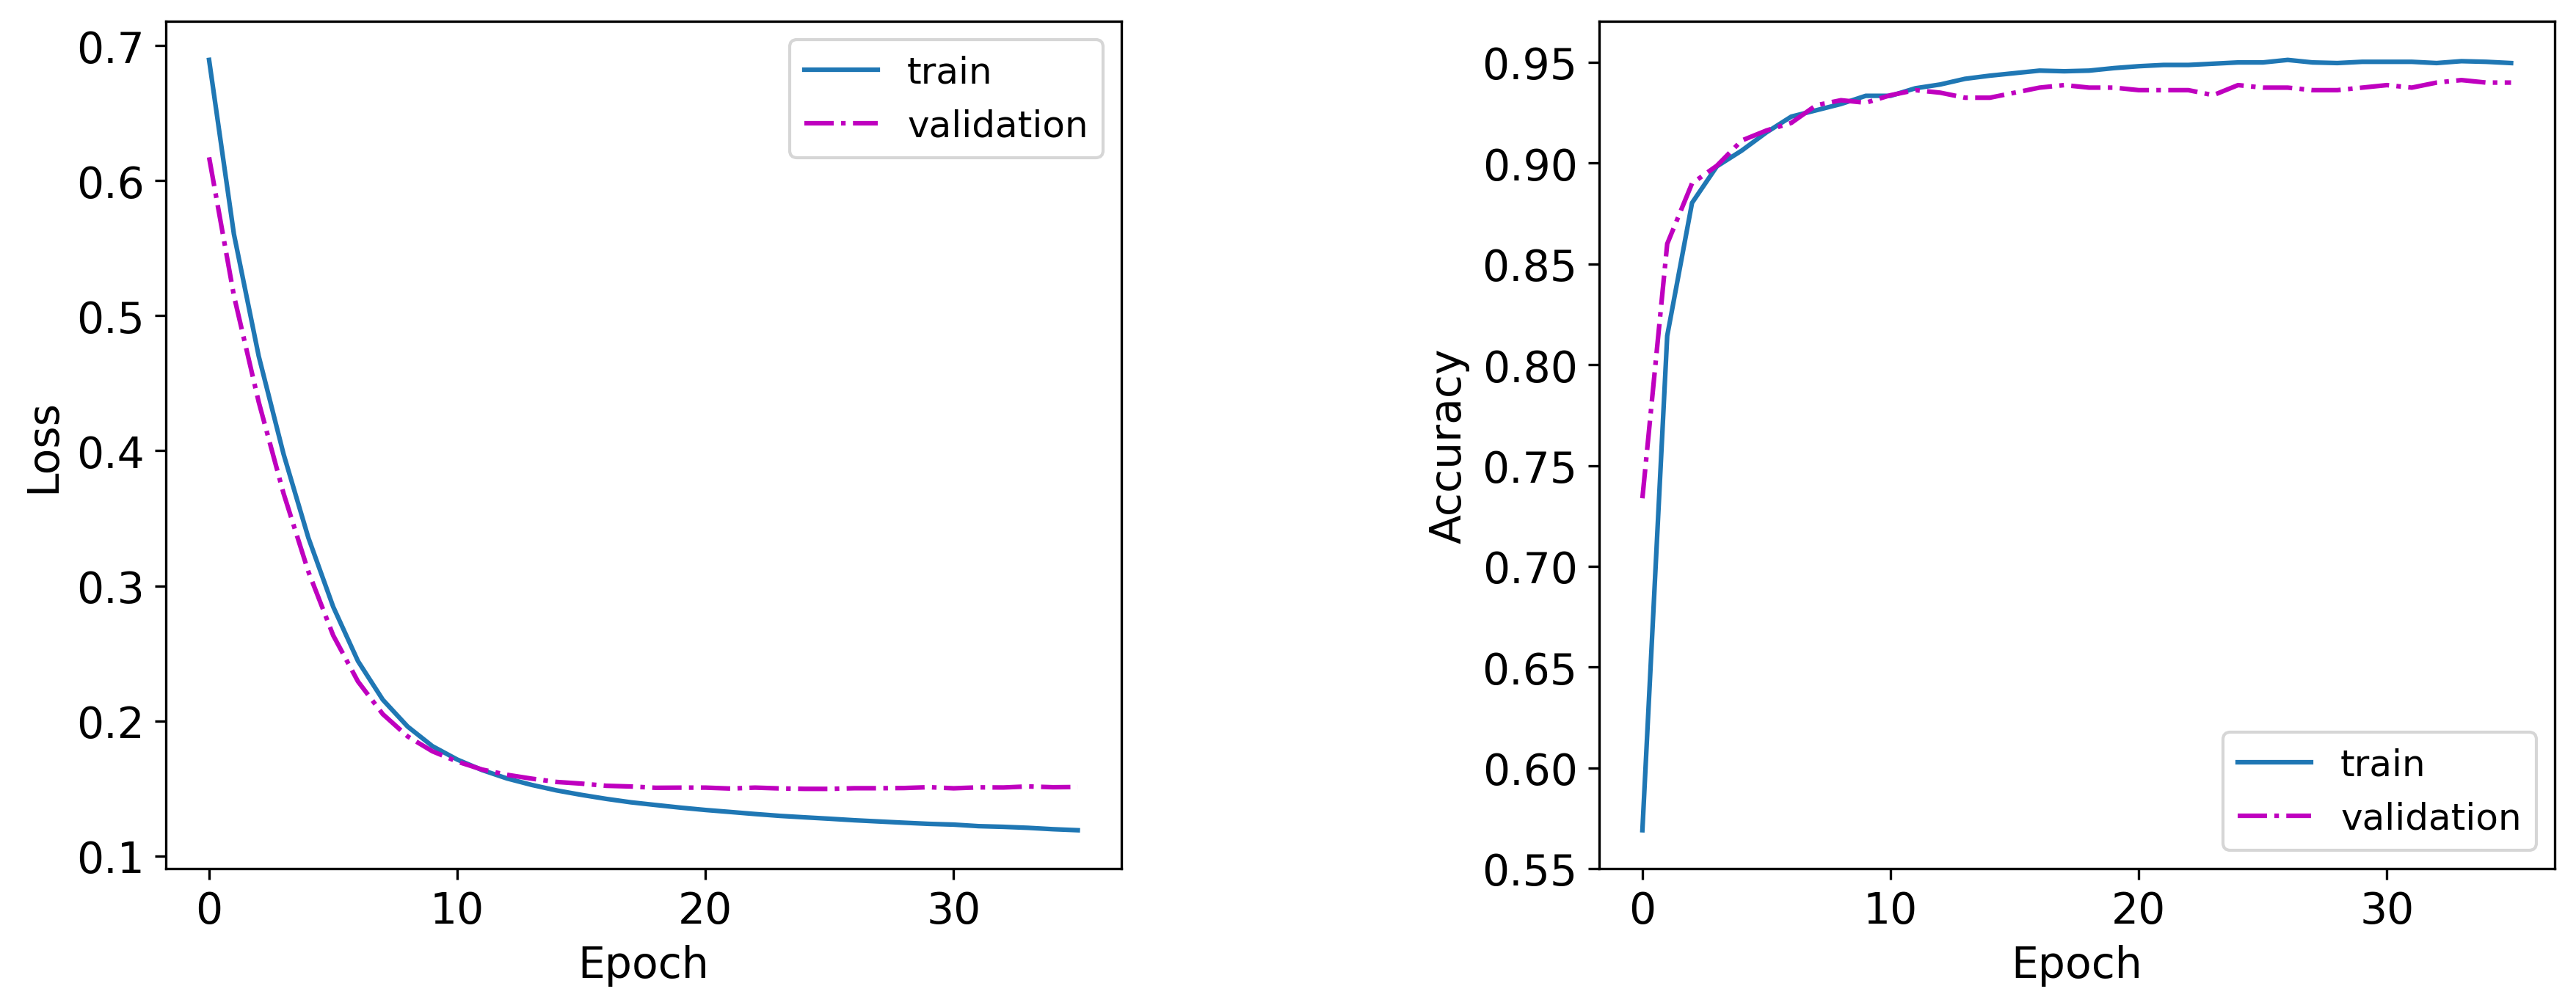

In [49]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_early.history['loss'], label = 'train')
plt.plot(mynet_early.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_early.history['accuracy'], label = 'train')
plt.plot(mynet_early.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('Regularized_Early_NN.png', dpi= 300)
#plt.show()

In [50]:
comparacion = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado + dropout",
     "val_acc": mynet_dropout.history['val_accuracy'][-1],
     "val_loss": mynet_dropout.history['val_loss'][-1]},
    {"modelo": "escalado + early stopping",
     "val_acc": mynet_early.history['val_accuracy'][-1],
     "val_loss": mynet_early.history['val_loss'][-1]},
])
comparacion

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.94750,0.160888
1,escalado + dropout,0.94875,0.154027
2,escalado + early stopping,0.94000,0.151009


In [51]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

modelos = {
    "sin regularizar": model_st,
    "dropout": model_dropout,
    "early stopping": model_early,
}

for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict(Xst_test, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["ttbar", "4top"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()

=== sin regularizar ===
              precision    recall  f1-score   support

       ttbar       0.96      0.97      0.97       838
        4top       0.83      0.81      0.82       162

    accuracy                           0.94      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.94      0.94      0.94      1000

AUC-ROC: 0.9731
Matriz de confusión:
[[811  27]
 [ 31 131]]

=== dropout ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.86      0.85       162

    accuracy                           0.95      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9786
Matriz de confusión:
[[812  26]
 [ 22 140]]

=== early stopping ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.85      0.84       16

In [52]:
comparacion = pd.DataFrame([
    {
        "modelo": nombre,
        "val_acc": modelo.evaluate(Xst_val, y_val, verbose=0)[1],
        "test_auc": roc_auc_score(y_test, modelo.predict(Xst_test, verbose=0).ravel()),
        "epocas": len(modelo.history.history['loss']) if hasattr(modelo, 'history') else None,
    }
    for nombre, modelo in modelos.items()
])
comparacion

,modelo,val_acc,test_auc,epocas
0,sin regularizar,0.94750,0.973106,100
1,dropout,0.94875,0.978572,100
2,early stopping,0.93750,0.976576,36


### Después de correr ambas: reflexión

Mire los números reales de dropout y early stopping.

1. Esperaba ese resultado? Explique
2. Dropout actúa *durante* el entrenamiento (apagando neuronas en cada paso). Early stopping actúa *deteniendo* el entrenamiento en un punto. ¿Por qué una de las dos estrategias podría funcionar mejor que la otra en este dataset específico, dado su tamaño y la arquitectura que están usando?
3. ¿Tendría sentido combinar ambas (dropout + early stopping) en vez de elegir una sola? ¿Por qué sí o por qué no?
4. Pruebe distintos valores de dropout y early stopping y discuta cómo cambian los resultados.


Respuestas:
1. Relativamente. Aunque Early Stopping resultó ser el más rápido, también tuvo el peor accuracy de validación. Dropout en realidad terminó siendo el de mejor accuracy.
2. En este caso particular, el overfitting es leve y manejable en ciertas épocas. Es probable que early stopping se detenga demasiado pronto antes de que haya una convergencia total. Dropout, sin embargo, va apagando estas neuronas de forma aleatoria (no hay sesgo) y terminó produciendo probabilidades más confiables. En este dataset de 3.200 ejemplos, es suficientemente grande para que el modelo se sostenga sin regularizar o utilizando early stopping.
3. Sí, ya que dropout reduce la covarianza entre neuronas y early stopping evita un tipo de memorización tardía. Ambos mecanismos pueden combinarse y, en este caso, el beneficio sería modesto dado que el overfitting ya es leve.
4. Para Dropout mientras mayor es el valor el validation accuracy empieza a bajar y el validation loss sube apenas, probablemente porque dropout empieza a eliminar demasiada información.
Para Early Stopping, mientras mayor sea su paciencia mejora levemente el validation accuracy y el validation loss disminuye progresivamente. Notamos que con `patience = 25` funciona similar a sin regularizar.

In [53]:
#Para variar los valores de dropout
for vals in [0.1, 0.3, 0.5, 0.8]:
  model_i = Sequential([Dense(20, activation = "relu", input_shape = (24,)),
                        Dropout(vals),
                        Dense(20, activation = "relu"),
                        Dropout(vals),
                        Dense(1, activation = "sigmoid")])

  #Para compilar cada modelo
  optimizer_i = tf.keras.optimizers.Adam(learning_rate = 0.001)
  model_i.compile(loss = "binary_crossentropy", optimizer = optimizer_i, metrics = ["accuracy"])

  #Para entrenar el modelo
  net_i = model_i.fit(Xst_train, y_train, validation_data = (Xst_val, y_val), epochs = 100, batch_size = 200, verbose = 0)

  print(f"Validation Accuracy para dropout = {vals}: {net_i.history['val_accuracy'][-1]:.4f}")
  print(f"Validation Loss para dropout = {vals}: {net_i.history['val_loss'][-1]:.4f}")
  print("--------------------")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy para dropout = 0.1: 0.9388
Validation Loss para dropout = 0.1: 0.1574
--------------------
Validation Accuracy para dropout = 0.3: 0.9400
Validation Loss para dropout = 0.3: 0.1505
--------------------
Validation Accuracy para dropout = 0.5: 0.9413
Validation Loss para dropout = 0.5: 0.1432
--------------------
Validation Accuracy para dropout = 0.8: 0.8512
Validation Loss para dropout = 0.8: 0.2175
--------------------


In [54]:
#Ahora para variar valores del early stopping

for pat_id in [5, 15, 20, 25]:
  model_i = Sequential([
      Dense(20, activation = "relu", input_shape = (24,)),
      Dense(20, activation = "relu"),
      Dense(1, activation = "sigmoid")
  ])

  #Para compilar cada modelo
  optimizer_i = tf.keras.optimizers.Adam(learning_rate = 0.001)
  model_i.compile(loss = "binary_crossentropy", optimizer = optimizer_i, metrics = ["accuracy"])

  #Para definir cuando detenerse
  es = EarlyStopping(monitor = "val_loss", patience = pat_id, restore_best_weights = True)

  #Para entrenar el modelo
  net_i = model_i.fit(Xst_train, y_train, validation_data = (Xst_val, y_val), epochs = 100, batch_size = 200, verbose = 0, callbacks=[es])

  print(f"Validation Accuracy para patience={pat_id}: {net_i.history['val_accuracy'][-1]:.4f}")
  print(f"Validation Loss para patience={pat_id}: {net_i.history['val_loss'][-1]:.4f}")
  print(f"Se detuvo en la época: {len(net_i.history['loss'])}")
  print("--------------------")

Validation Accuracy para patience=5: 0.9400
Validation Loss para patience=5: 0.1577
Se detuvo en la época: 23
--------------------
Validation Accuracy para patience=15: 0.9450
Validation Loss para patience=15: 0.1462
Se detuvo en la época: 35
--------------------
Validation Accuracy para patience=20: 0.9375
Validation Loss para patience=20: 0.1512
Se detuvo en la época: 38
--------------------
Validation Accuracy para patience=25: 0.9438
Validation Loss para patience=25: 0.1557
Se detuvo en la época: 43
--------------------


### Optimización de hiperparámetros

Usaremos [`keras_tuner`](https://keras.io/keras_tuner/) para optimizar los hiperparámetros de la arquitectura de la red

### Antes de correr la búsqueda

Con lo que ya sabe del dataset y de los experimentos anteriores, responda:

- ¿Cuántas capas ocultas cree que va a preferir el mejor modelo?
- ¿Dropout va a terminar en 0.0 o en un valor alto?
- ¿El learning rate óptimo va a ser más cercano a 0.0001 o a 0.01?


Respuestas:
1. Probablemente el modelo prefiera dos, ya que es la que aprendimos antes que funciona bastante bien y turner penaliza arquitecturas más complejas.
2. Puede terminar en un valor bajo, rondando el 0.0 o 0.3. El overfitting en este caso es leve y el dropout alto terminaría por perjudicar esta convergencia, sobre todo cuando el learning rate empieza a aumentar.
3. Probablemente más cerca de 0.01, ya que el turner favorece estos learning rates más "agresivos" que convergen mucho más rápido.

In [55]:
#pip install keras-tuner  #(correr una vez en Colab)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.2 MB/s eta 0:00:00


In [56]:
import keras_tuner as kt

def build_model_tuner(hp):
    model = Sequential()

    #prueba con ndistintos numeros de neuronas, desde 8 a 64, cada 8,
    n_neurons = hp.Int("n_neurons", min_value=8, max_value=64, step=8)
    # activation = hp.Choice("activation", values=["relu", "tanh"])

    #construye la capa con la cantidad de neuronas que fijo en el paso anterior (cada capa con el mismo numero de neuronas)
    model.add(Dense(n_neurons, activation='relu', input_shape=(24,)))

    #numero de capas ocultas (1, 2, o 3)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))

    #tasa de dropout (0.1-0.5, en pasos de 0.1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    #la capa de salida queda fija, para la clasificacion binaria
    model.add(Dense(1, activation='sigmoid'))

    #tasa de aprendizaje, entre 0.0001 y 0.01
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

#prueba solo combinaciones aleatorias para reducir costo computacional
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_accuracy",
    max_trials=15,          # número de combinaciones a probar
    executions_per_trial=1,
    directory="tuner_resultados",
    project_name="particle_id",
)

tuner.search(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=30,
    batch_size=200,
    verbose=1,
)

Trial 15 Complete [00h 00m 08s]
val_accuracy: 0.9474999904632568

Best val_accuracy So Far: 0.949999988079071
Total elapsed time: 00h 02m 54s


In [57]:
# Mejor modelo encontrado
mejores_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros:")
for param in mejores_hp.values:
    print(f"  {param}: {mejores_hp.values[param]}")

Mejores hiperparámetros:
  n_neurons: 48
  n_hidden: 3
  dropout_rate: 0.30000000000000004
  learning_rate: 0.000328831566908209


### Evaluamos finalmente el modelo con el set de prueba, que sólo se usa en el paso final

In [58]:
mejor_modelo = tuner.get_best_models(1)[0]
scores = mejor_modelo.evaluate(Xst_test, y_test, verbose=0)
print(f"\nAccuracy en test: {scores[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Accuracy en test: 0.9450


In [59]:
# Resumen de los mejores trials
tuner.results_summary(num_trials=5)

Results summary
Results in tuner_resultados/particle_id
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 11 summary
Hyperparameters:
n_neurons: 48
n_hidden: 3
dropout_rate: 0.30000000000000004
learning_rate: 0.000328831566908209
Score: 0.949999988079071

Trial 00 summary
Hyperparameters:
n_neurons: 64
n_hidden: 1
dropout_rate: 0.4
learning_rate: 0.0020853562398959924
Score: 0.9487500190734863

Trial 04 summary
Hyperparameters:
n_neurons: 32
n_hidden: 1
dropout_rate: 0.1
learning_rate: 0.000737956160144406
Score: 0.9487500190734863

Trial 14 summary
Hyperparameters:
n_neurons: 64
n_hidden: 1
dropout_rate: 0.0
learning_rate: 0.003437632621059782
Score: 0.9474999904632568

Trial 01 summary
Hyperparameters:
n_neurons: 40
n_hidden: 1
dropout_rate: 0.4
learning_rate: 0.001846808222764879
Score: 0.9462500214576721


### Mire los 5 mejores trials, no solo el ganador


1. ¿Hay algún empate o casi-empate en el score entre dos trials? Compare sus arquitecturas (n_neurons, n_hidden) y su dropout_rate uno al lado del otro, ¿qué tan distintos son entre sí?

2. Si encuentra un caso así, ¿qué le dice eso sobre la relación entre tamaño de red y necesidad de regularización? ¿es dropout algo que "siempre ayuda", o depende de si la arquitectura ya es lo suficientemente chica como para no necesitarlo?

3. Si tuviera que elegir entre dos modelos con score casi igual pero muy distintos en complejidad, ¿cuál elige para poner en producción y por qué? (piense en costo de cómputo, riesgo de overfitting futuro, interpretabilidad)

4. Compare el mejor modelo de la búsqueda automática contra su mejor intento manual (dropout o early stopping). ¿Vale la pena el costo computacional de la búsqueda para esa diferencia?



Respuestas:
1. Sí, hay un empate entre Trial 00 y Trial 03, ambos con un `val_accuracy` de aproximadamente 0.94125. Sus arquitecturas difieren en que Trial 00 es una red más grande y compleja con 64 neuronas, tres capas ocultas y un dropout moderado. Trial 03, sin embargo, tiene 8 neuronas y una capa oculta con un dropout bajo, lo que la vuelve una red pequeña y simple.
Esto sugiere que se pueden lograr rendimientos similares con arquitecturas muy diferentes, donde resalta más la importancia de buscar hiperparámetros y la posibilidad de encontrar soluciones más eficientes y menos complejas.

2. El hecho de que Trial 03 (una red notoriamente pequeña) logre un rendimiento similar comparandolo con una red grande y compleja de menor dropout sugiere que el dropout no necesariamente siempre ayudar de la misma forma.
En este caso, para redes más pequeñas podrían beneficiarse menos si el dropout es alto, Es totalmente contrario a cuando tenemos redes muy grandes, ya que este dropout alto es a menudo necesario para prevenir el overfitting. Básicamente, el valor óptimo de dropout depende del tamaño y complejidad de la red para ajustarla lo mejor posible.

3. Entre un modelo complejo y uno más sencillo, es mejor elegir un modelo con menor complejidad para este caso. Más que nada por el costo computacional, ya que un modelo más simple requiere de menos recursos para el entrenamiento, por la forma en que el overfitting es menos propenso y por una adaptabilidad más o menos manejable en comparación de un modelo muy complejo.

4. El mejor modelo de keras turner en la tabla es de Trial 01, con un `val_accuracy: 0.95125`. En el intento manual, el mejor resultado obtenido fue early stopping con un `val_accuracy: 0.94125`. Si bien la diferencia no es tan grande (alrededor del 1%), la configuración óptima que encuentra keras_turner ayuda a manejar una arquitectura mucho más simple y eficiente. En este caso, aunque la diferencia no es importante y la situación es bastante manejable, si vale la pena este costo computacional.

### Reflexión final

1. A lo largo de este notebook probó varios modelos: sin escalar, escalado, con dropout, con early stopping, y el resultado de la búsqueda automática de hiperparámetros. ¿Cuál de todos eligiría como el modelo final, y por qué? Use números concretos de sus tablas, no solo accuracy.

2. El SVM del notebook anterior llegó a 94-95%. ¿Su mejor red neuronal lo superó? Si la diferencia es chica, ¿vale la pena toda la complejidad extra (arquitectura, regularización, búsqueda de hiperparámetros) por esa ganancia?

3. Comparen el salto de accuracy entre "sin escalar → escalado" contra el salto entre "escalado sin regularizar → mejor modelo de la búsqueda de hiperparámetros". ¿Cuál salto fue más grande? ¿Qué les dice eso sobre dónde conviene invertir tiempo primero cuando entrenan una red nueva?

Respuestas:
1. Entre todos los modelos, el mejor resultado fue de Trial 01. En resumen, los resultados de este intento son los siguientes:

   `val_accuracy` de 0.95125 y `test_auc` de 0.9791. Esta configuración no usa dropout (`dropout_rate: 0.0`) y tiene una sola capa oculta (`n_hidden: 1`) con 56 neuronas, además de un `learning_rate` optimizado (`0.00618`).

Y aunque  el `test_auc`del modelo Early Stopping sea casi idéntico al de Turner, el modelo de Turner logró un accuracy mayor y, más importante aún, encontró una arquitectura mucho más simple (de una capa oculta, sin dropout) que logra este rendimiento tan bueno.

2. El mejor `val_accuracy` obtenido fue de 0.95125, que comparándolo con el SVM anterior se mantiene dentro del rango. En este caso particular, la ganancia es relativamente pequeña si estamos hablando de una mejora tan poco significativa.
Además, las redes neuronales introducen una complejidad notoria en comparación a SVM que necesita mucha mas regularización y un entendimiento de su  arquitectura. Es añadirle un peso extra computacional que en un caso de juguete no se ve totalmente justificado.

3. Observando los datos, notaremos que el "salto" más grande que podemos ver es entre "sin escalar a escalado", pasando de un 22.13% vs un 0.745%
Esto nos puede indicar que la normalización de los datos es un paso sumamente importante que se debe realizar antes de entrenar una red neuronal. Un buen preprocesamiento puede mejorar el aprendizaje del modelo notoriamente.